# Lab 5

In [2]:
### MATPLOTLIB SETUP ###
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
pd.set_option('display.float_format', lambda x: '%e' % x)

## Amit's library with some utility functions for reading and processing scope data; reproduced below
sys.path.append("../../")
from lib import *

from rich.console import Console
from rich.syntax import Syntax
# Console().print(Syntax.from_path("../../lib.py", line_numbers=True, theme="monokai"))

## Jupyter magic
%matplotlib
%matplotlib ipympl
%load_ext autoreload
%autoreload 2

Using matplotlib backend: ipympl
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Prelab

### Creating digital twin

I first modified my buck converter circuit into a flyback converter by replacing the inductor with a transformer, and adjusting the wiring to match the hardware confugration like so. I chose to represent the magnetizing inductance L inside of the transformer, and set the turns ratio to the variable a.

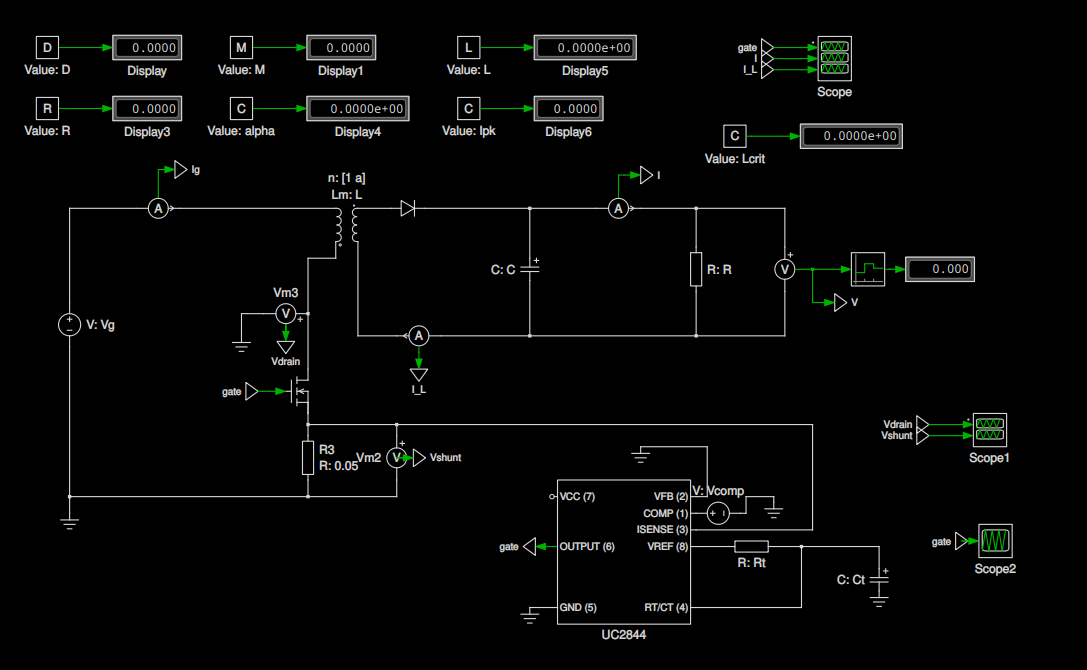

Additionally, I also set up my constant parameters like so (some from the prelab, some from the circuit)

```matlab
Rt = 7.87e3;
Ct = 2.2e-9;
Ts=2.0617e-5; % measured in scope
fs=1/Ts;

D = 0.35;
C=60e-6;
Vg=18;
Vo=10;
R=5;
alpha = 0.7
```

### Calculating L and Ipk

Based on the buck-boost equation from the lectures, I calculated Lcrit like so

$$
L_{crit} = (\frac{1}{M+1})^2 * (\frac{R}{a^2}) * (\frac{T_s}{2})
$$

Note that M is $\frac{V_o}{a*V_g}$, and $R$ is divided by $a^2$ to match the buck boost configuration.

With $L_{crit}$ in hand, we can multiply it by $\alpha$ to find our final L value. This was done with the following setup script code

```matlab
Lcrit = (1/(M+1))^2 * (R/a^2) * (Ts/2)
L = Lcrit * alpha
```

and yielded an inductance of $20.45 uH$

For Ipk, I used the Ipk DCM equation from the lecture notes

$$
I_{pk} = \sqrt{K} * T_s * (\frac{V_i}{L})
$$

where $K = \frac{2}{T_s} * \frac{L}{R}$, and $V_i$ is the voltage on the left side of the transformer (eq. to the buck boost output voltage).

This yielded an $I_{pk}$ of 6.35 amps

### Verifying calculations

Entering these calculations into my PLECS sim (and adjusting my frequency to match the one I measured earlier on the PLECS scope) output a voltage of 10.0002 V, which is very (surprisingly, in fact) accurate.4

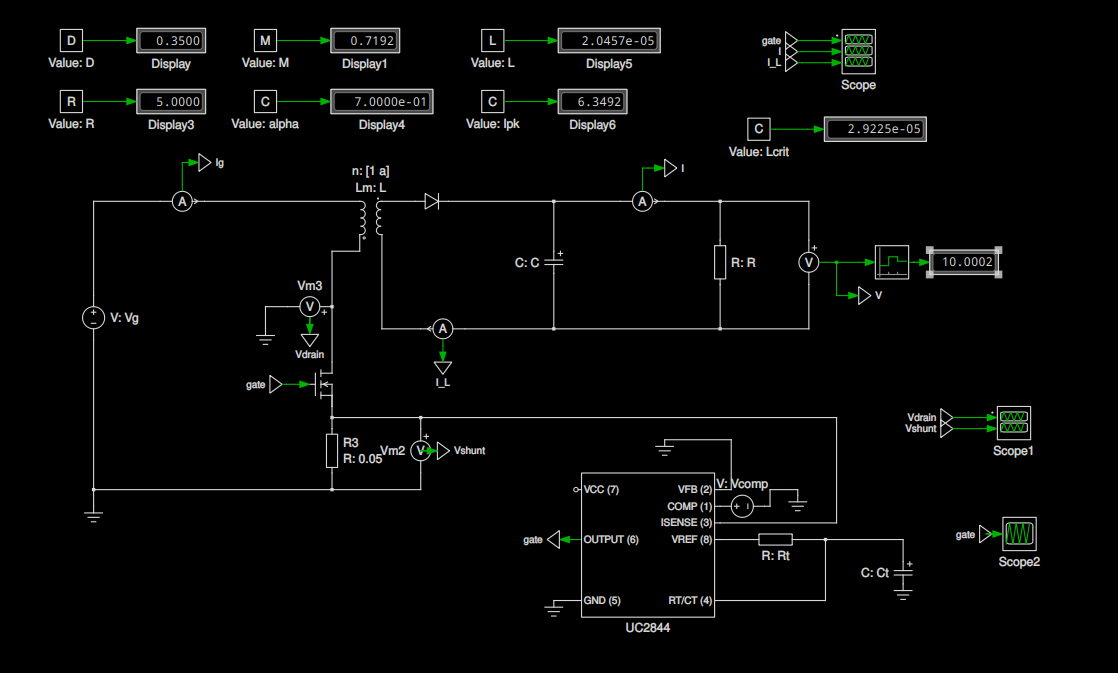